# Customer Segmentation Using RFM Analysis

This project performs customer segmentation using Recency, Frequency,
and Monetary (RFM) analysis on an e-commerce dataset.

The objective is to identify high-value customers and provide
actionable business insights for marketing and retention strategies.

## Business Problem

E-commerce companies need to understand customer behavior to:

- Identify high-value customers
- Improve customer retention
- Optimize marketing campaigns
- Increase revenue

This project answers:
- Who are the best customers?
- Which customers are at risk?
- How can we segment customers effectively?

In [63]:
!pip install openpyxl

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset

Dataset Source: UCI Machine Learning Repository

The dataset contains transactional data including:
- CustomerID
- InvoiceDate
- Quantity
- UnitPrice

## Data Loading

In [65]:
df = pd.read_excel("Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Data Understanding

We explore the dataset structure, data types, and size.

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [67]:
df.shape

(541909, 8)

## Data Cleaning

We clean the dataset by:
- Removing missing Customer IDs
- Removing negative quantities (returns)
- Removing invalid prices

In [68]:
df = df.dropna(subset=["CustomerID"])

In [69]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

In [70]:
df = df[df["Quantity"] > 0]

In [71]:
df = df[df["UnitPrice"] > 0]

## Feature Engineering

We create new features required for RFM analysis:

- Revenue = Quantity × UnitPrice
- Recency = Days since last purchase
- Frequency = Number of purchases
- Monetary = Total spending

In [72]:
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## RFM Calculation

In [73]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

snapshot_date

Timestamp('2011-12-10 12:50:00')

In [74]:
recency = df.groupby("CustomerID")["InvoiceDate"].max()

recency = (snapshot_date - recency).dt.days

In [75]:
frequency = df.groupby("CustomerID")["InvoiceNo"].nunique()

In [76]:
monetary = df.groupby("CustomerID")["Revenue"].sum()

In [77]:
rfm = pd.DataFrame({
    "Recency": recency,
    "Frequency": frequency,
    "Monetary": monetary
})

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


## RFM Summary

In [78]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,307.415000
50%,51.000000,2.000000,674.485000
75%,142.000000,5.000000,1661.740000
max,374.000000,209.000000,280206.020000


In [79]:
rfm["R_score"] = pd.qcut(rfm["Recency"], 4, labels=[4,3,2,1])

In [80]:
rfm["F_score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    4,
    labels=[1,2,3,4]
)

In [81]:
rfm["M_score"] = pd.qcut(
    rfm["Monetary"],
    4,
    labels=[1,2,3,4]
)

In [82]:
rfm["RFM_Score"] = (
    rfm["R_score"].astype(str) +
    rfm["F_score"].astype(str) +
    rfm["M_score"].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,4,114
12347.0,2,7,4310.00,4,4,4,444
12348.0,75,4,1797.24,2,3,4,234
12349.0,19,1,1757.55,3,1,4,314
12350.0,310,1,334.40,1,1,2,112


In [83]:
def segment_customer(row):

    if row["RFM_Score"] == "444":
        return "Best Customers"

    elif int(row["F_score"]) >= 3:
        return "Loyal Customers"

    elif int(row["R_score"]) <= 2:
        return "At Risk"

    else:
        return "Regular Customers"

rfm["Segment"] = rfm.apply(segment_customer, axis=1)

In [84]:
rfm["Segment"].value_counts()

,count
Segment,
Loyal Customers,1679
At Risk,1504
Regular Customers,665
Best Customers,490


In [85]:
segment_revenue = rfm.groupby("Segment")["Monetary"].sum()

segment_revenue

,Monetary
Segment,
At Risk,767146.842
Best Customers,4434743.730
Loyal Customers,3207564.112
Regular Customers,501953.220


## Data Visualization

### RFM Distribution
This shows how customers are distributed across recency, frequency, and spending.

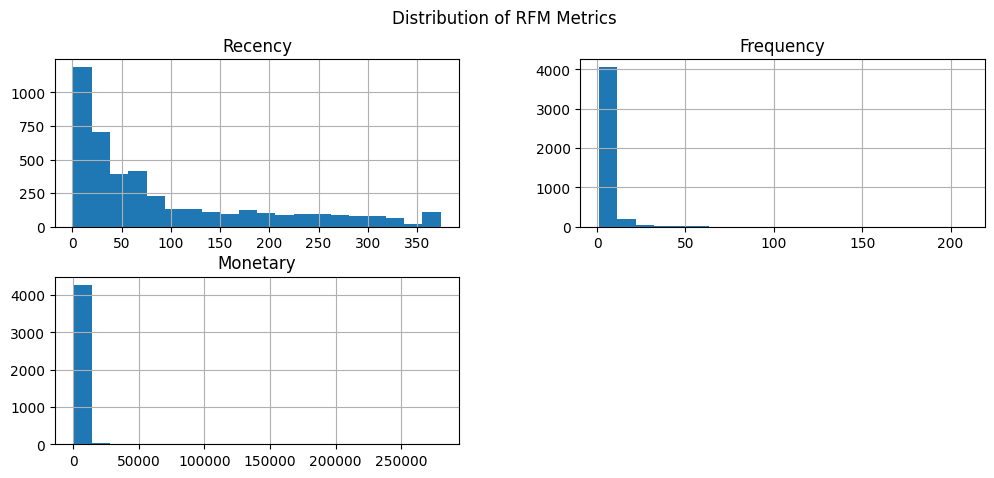

In [86]:
rfm.hist(figsize=(12,5), bins=20)

plt.suptitle("Distribution of RFM Metrics")

plt.show()

### Customer Segments
This shows how customers are divided into different segments.

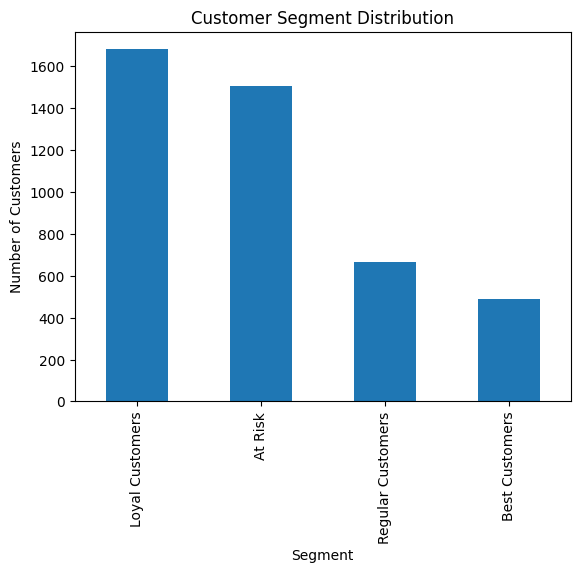

In [87]:
rfm["Segment"].value_counts().plot(kind="bar")

plt.title("Customer Segment Distribution")

plt.xlabel("Segment")

plt.ylabel("Number of Customers")

plt.show()

### Revenue Contribution
This shows which customer segments generate the most revenue.

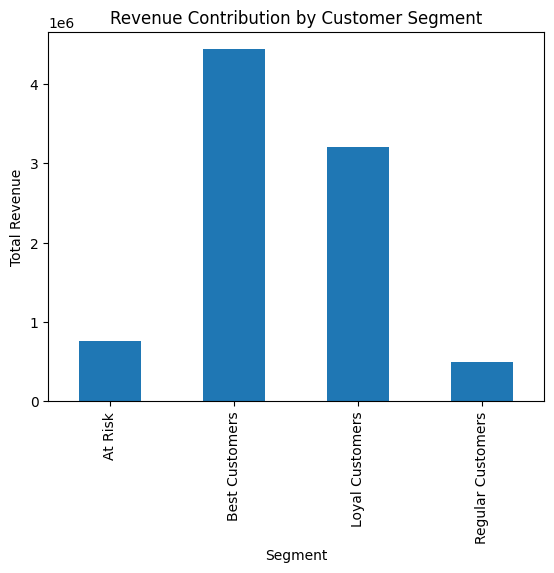

In [88]:
segment_revenue.plot(kind="bar")

plt.title("Revenue Contribution by Customer Segment")

plt.xlabel("Segment")

plt.ylabel("Total Revenue")

plt.show()

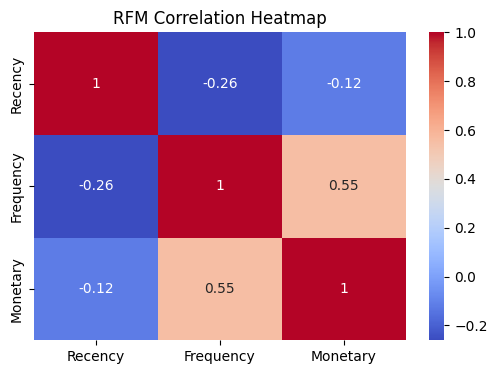

In [89]:
plt.figure(figsize=(6,4))

sns.heatmap(
    rfm[["Recency","Frequency","Monetary"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("RFM Correlation Heatmap")

plt.show()

## Customer Segmentation

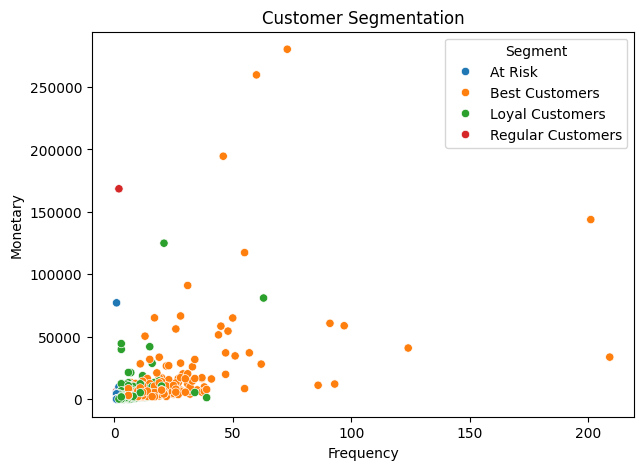

In [90]:
plt.figure(figsize=(7,5))

sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Segment"
)

plt.title("Customer Segmentation")

plt.show()

## Key Business Insights

1. Best customers contribute the highest revenue.
2. Loyal customers purchase frequently and should be retained.
3. At-risk customers need re-engagement strategies.
4. Regular customers can be converted into loyal customers.

## Conclusion

RFM analysis helps businesses identify customer value and
design targeted marketing strategies to improve retention
and revenue.